# Group analysis of columns data

## Load data

In [30]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_valid.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

type = 'ad'

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S03017', 'S02266', 'S02363', 'S02765', 'S01621', 'S03225', 'S03343', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987', 'S02485', 'S01412']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',
       'ethnicity',

In [31]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [32]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [33]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel(type)
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + type + '_' + region + '.png')
    plt.close()


In [34]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

In [35]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.67825758 -0.93189112 -0.85539892]
 [-2.12139645  1.07308674  1.16904519]
 [-1.02286429 -0.93189112  1.16904519]
 [-0.36858664 -0.93189112 -0.85539892]
 [ 1.0053964  -0.93189112  1.16904519]
 [-0.56486994  1.07308674 -0.85539892]
 [ 0.92034031 -0.93189112 -0.85539892]
 [-1.80799746  1.07308674 -0.85539892]
 [-1.41543087  1.07308674 -0.85539892]
 [ 0.52515662 -0.93189112 -0.85539892]
 [ 0.08940771  1.07308674 -0.85539892]
 [-0.65516025 -0.93189112  1.16904519]
 [-0.76115323 -0.93189112 -0.85539892]
 [ 1.66817966  1.07308674 -0.85539892]
 [ 1.9213851  -0.93189112 -0.85539892]
 [ 0.22026323  1.07308674  1.16904519]
 [-0.49944217  1.07308674 -0.85539892]
 [-2.06970851 -0.93189112  1.16904519]
 [-1.41543087 -0.93189112 -0.85539892]
 [-0.95743652 -0.93189112 -0.85539892]
 [ 0.8359385   1.07308674 -0.85539892]
 [-1.41543087 -0.93189112  1.16904519]
 [-0.69572547  1.07308674 -0.85539892]
 [ 0.74368535 -0.93189112 -0.85539892]
 [ 0.93996864  1.07308674  1.16904519]
 [ 0.54740206 -0.93189112

lh_bankssts
lh_caudalanteriorcingulate
Weights:
[[ 0.02569968  0.01153915 -0.00423886]
 [ 0.03381637  0.01180702 -0.00554066]
 [ 0.05839795  0.01125909 -0.00392641]]
MSE:
0.004553669550885196
R2:
0.25349298392946373


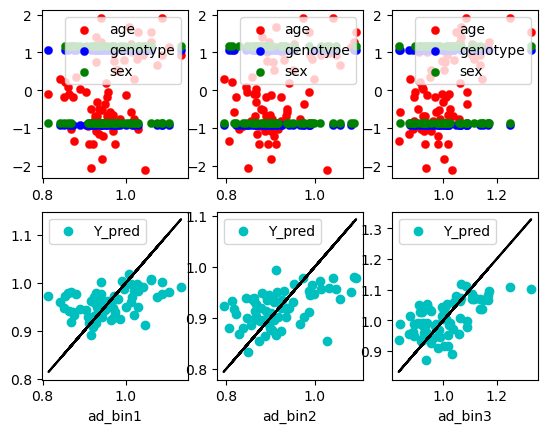

lh_caudalmiddlefrontal
Weights:
[[ 0.00797992 -0.00304112 -0.00169445]
 [ 0.01641364 -0.00559391  0.00068369]
 [ 0.06027415 -0.00949093  0.01141485]]
MSE:
0.002614048645859685
R2:
0.2241276319171197


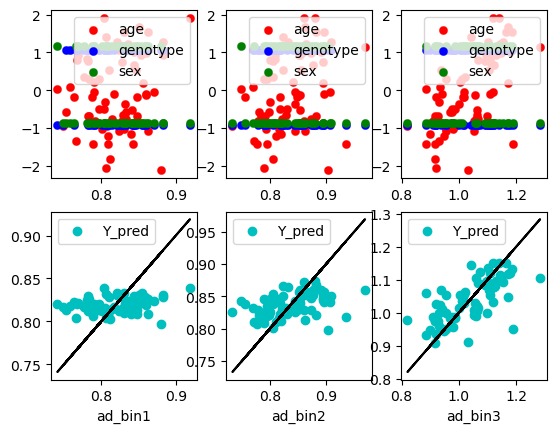

lh_cuneus
Weights:
[[ 0.01667318  0.00032586 -0.00676825]
 [ 0.02355321 -0.00843216  0.00980897]
 [ 0.05683031 -0.00482246  0.04146036]]
MSE:
0.003654102897488653
R2:
0.2695567734200745


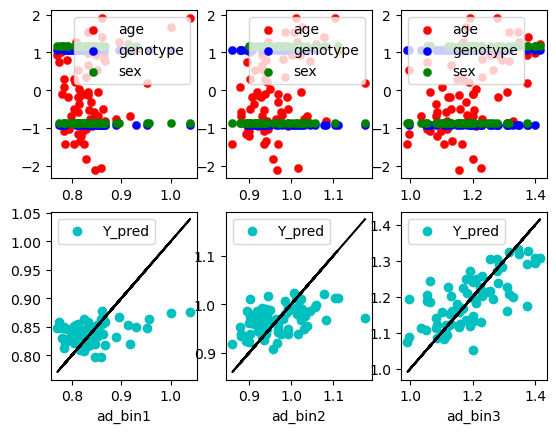

lh_entorhinal
lh_fusiform
Weights:
[[ 0.01054477  0.00451604 -0.00986426]
 [ 0.02553756  0.00412467 -0.0050395 ]
 [ 0.07184604  0.00477522  0.00186379]]
MSE:
0.0020991795462893376
R2:
0.360007715983224


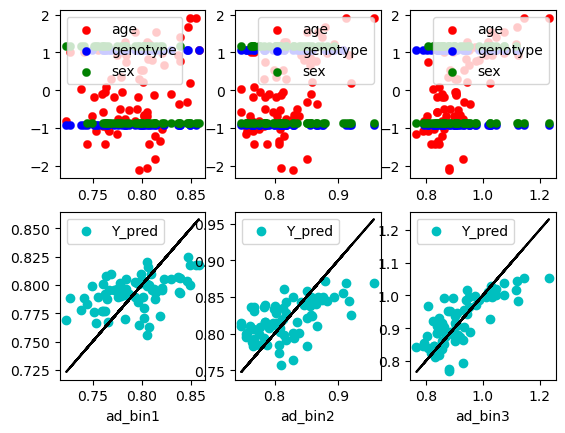

lh_inferiorparietal
Weights:
[[ 0.00896625 -0.00075479 -0.00268114]
 [ 0.01930378 -0.00114705 -0.00445854]
 [ 0.07164799  0.00242574  0.00952966]]
MSE:
0.0032646532411677903
R2:
0.22183589896803882


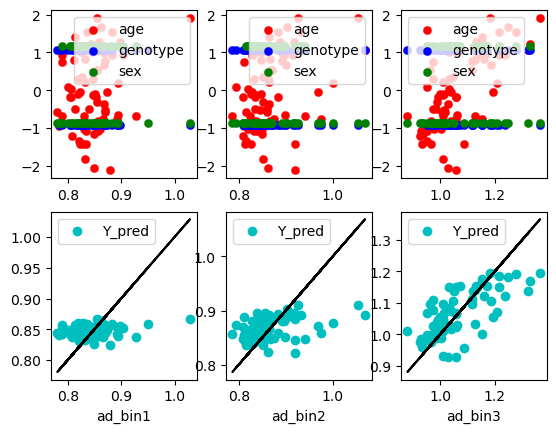

lh_inferiortemporal
Weights:
[[0.01192632 0.00344289 0.00072341]
 [0.02394166 0.00342798 0.00366365]
 [0.05473406 0.002837   0.00960461]]
MSE:
0.0029143379837451465
R2:
0.22396293136759984


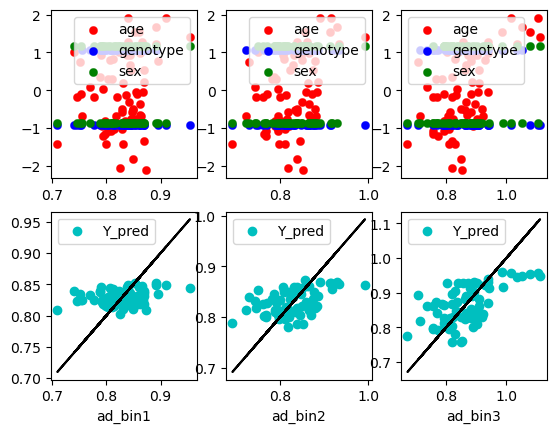

lh_isthmuscingulate
Weights:
[[ 0.0252376  -0.00028921 -0.00445976]
 [ 0.03950796  0.00199244  0.00605189]
 [ 0.06642249  0.00803733  0.0129113 ]]
MSE:
0.005246537117009309
R2:
0.2624465894429496


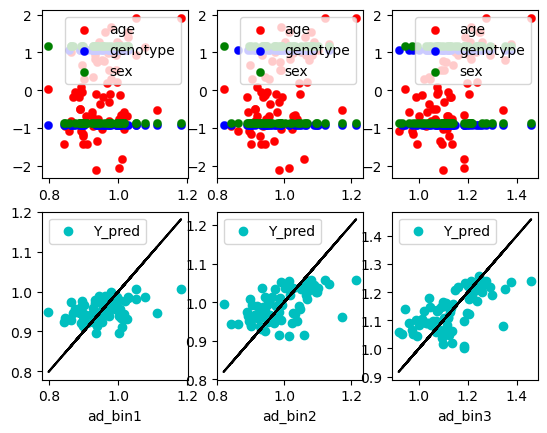

lh_lateraloccipital
Weights:
[[ 0.02618348  0.01068797 -0.01068731]
 [ 0.03704655  0.00663103  0.00274607]
 [ 0.05690895  0.00237033  0.03333332]]
MSE:
0.005924071023863899
R2:
0.2465857592131511


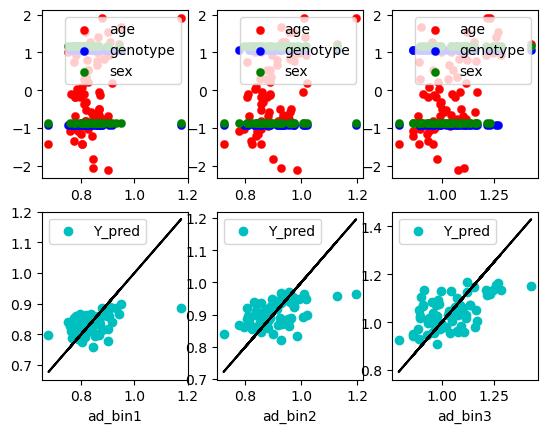

lh_lateralorbitofrontal
lh_lingual
Weights:
[[ 0.02163653 -0.0010492   0.00168797]
 [ 0.04001675 -0.00235767  0.01054174]
 [ 0.07786629  0.00113588  0.01528459]]
MSE:
0.005078441814648341
R2:
0.29330421302265497


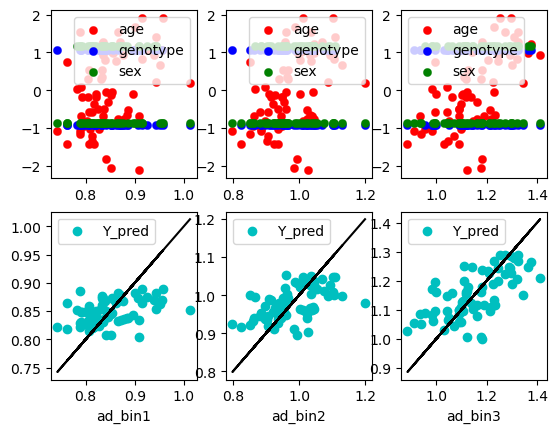

lh_medialorbitofrontal
lh_middletemporal
Weights:
[[ 0.00848189  0.00378054  0.00361631]
 [ 0.02217793  0.00219203  0.00288839]
 [ 0.06971219 -0.00448054  0.00777097]]
MSE:
0.002522523172570778
R2:
0.26769953610246494


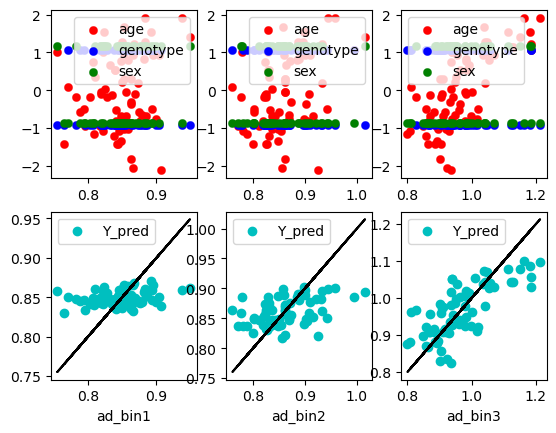

lh_parahippocampal
Weights:
[[ 0.01152901  0.0038981  -0.01543531]
 [ 0.02562209  0.00989331 -0.00728525]
 [ 0.05621258  0.01118731 -0.00290026]]
MSE:
0.0032019247055567537
R2:
0.25258203013516717


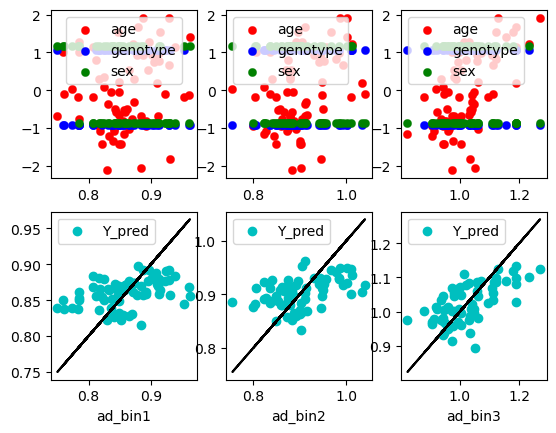

lh_paracentral
Weights:
[[ 0.01455193 -0.00708071 -0.00103805]
 [ 0.02483916 -0.00603373  0.00530114]
 [ 0.06773721 -0.01508355  0.03621869]]
MSE:
0.0035294146060442315
R2:
0.3065638002487509


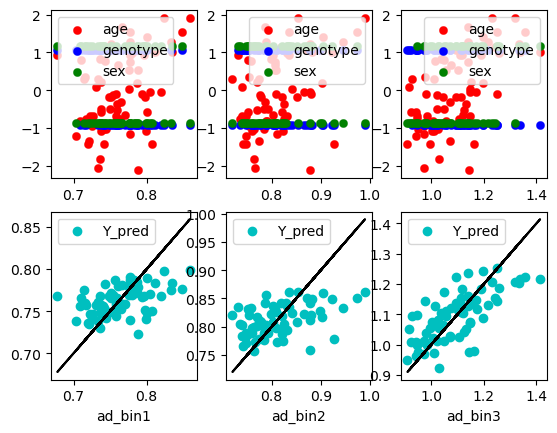

lh_parsopercularis
lh_parsorbitalis
lh_parstriangularis
Weights:
[[ 1.29468138e-02  3.78834230e-05 -5.92269019e-03]
 [ 2.52491303e-02  5.46515588e-03 -9.11479046e-03]
 [ 6.52800333e-02  1.36950207e-02  9.58045920e-03]]
MSE:
0.003489362430384505
R2:
0.24212399016707517


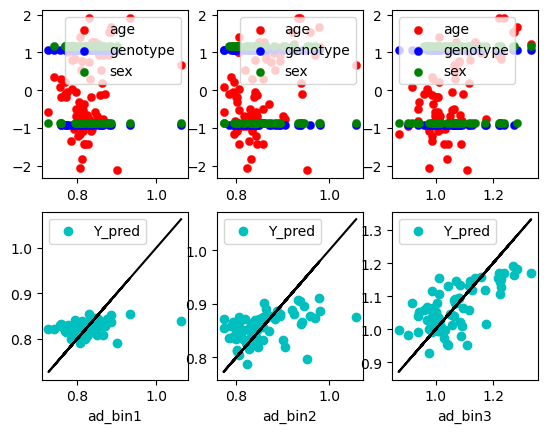

lh_pericalcarine
Weights:
[[ 0.03142517 -0.00184906 -0.00337774]
 [ 0.04785891 -0.0060448   0.01584261]
 [ 0.07225604  0.00148321  0.04587599]]
MSE:
0.0046661343552817204
R2:
0.396522870791766


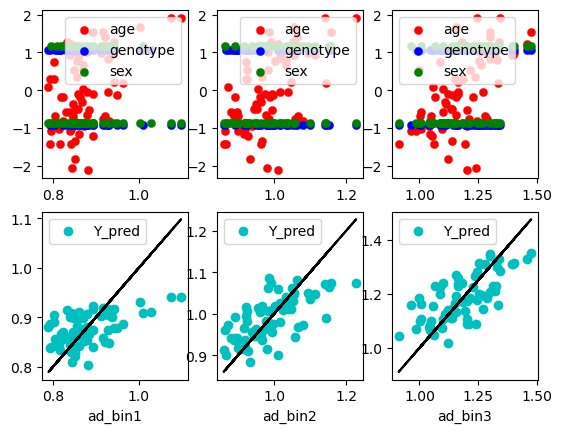

lh_postcentral
lh_posteriorcingulate
Weights:
[[ 2.23896200e-02 -4.38081755e-06  1.49929426e-03]
 [ 2.91088040e-02 -2.44166856e-03  2.34410662e-03]
 [ 6.39520662e-02 -3.10822905e-03  9.47702454e-03]]
MSE:
0.0030176184980351137
R2:
0.3334131542193041


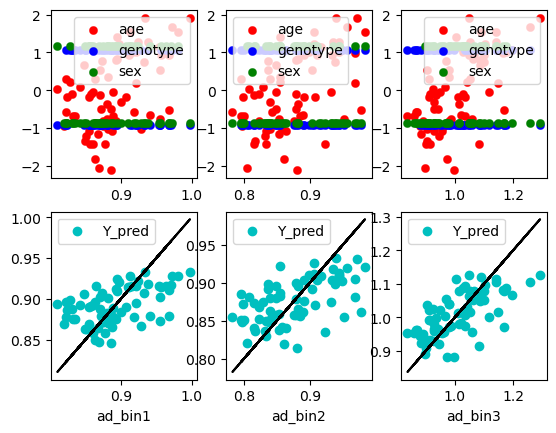

lh_precentral
lh_precuneus
Weights:
[[ 0.01135903 -0.00088984 -0.00351477]
 [ 0.02407717 -0.00266784 -0.00140754]
 [ 0.07105555  0.00228555  0.010652  ]]
MSE:
0.003041776821104283
R2:
0.26500693142394033


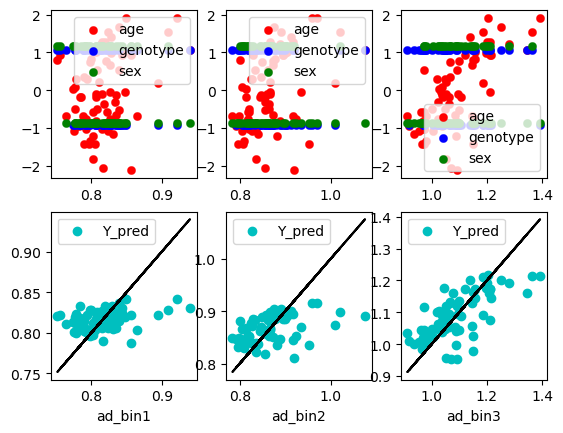

lh_rostralanteriorcingulate
Weights:
[[ 0.0287888   0.00530039 -0.00896338]
 [ 0.02429994  0.00386173 -0.00597762]
 [ 0.0387839   0.00087675 -0.00126327]]
MSE:
0.0035714365677894894
R2:
0.21176529982629785


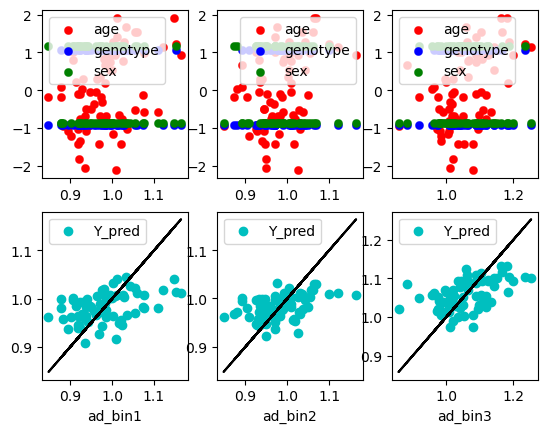

lh_rostralmiddlefrontal
lh_superiorfrontal
lh_superiorparietal
lh_superiortemporal
Weights:
[[ 0.00452979  0.00019927 -0.00152392]
 [ 0.01804955  0.00129761 -0.00709453]
 [ 0.06685317 -0.0002406  -0.00300509]]
MSE:
0.0028219134174718233
R2:
0.2066677223795381


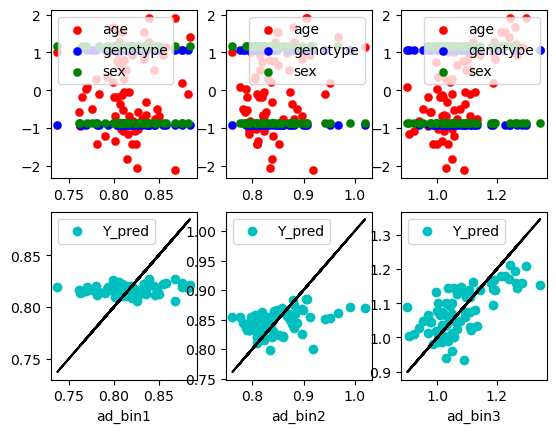

lh_supramarginal
Weights:
[[ 0.01019384 -0.00412111  0.00091246]
 [ 0.02350224 -0.00790926 -0.00397994]
 [ 0.07232279 -0.00465208  0.00351551]]
MSE:
0.0033561327385190436
R2:
0.25516332062616587


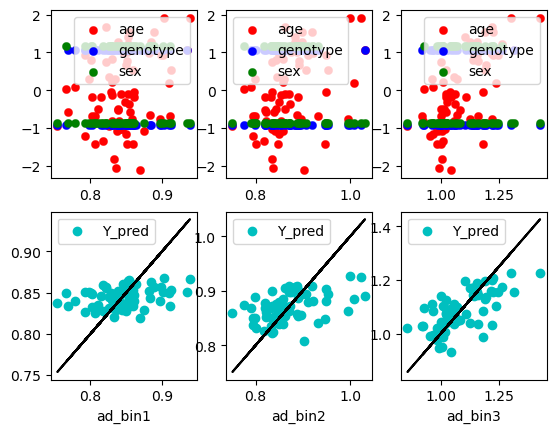

lh_frontalpole
lh_temporalpole
lh_transversetemporal
lh_insula
Weights:
[[ 0.01854405  0.00789869 -0.00080938]
 [ 0.01744047  0.00843134 -0.00380993]
 [ 0.0554683   0.01090578  0.00371101]]
MSE:
0.002601931884026366
R2:
0.26932055127058524


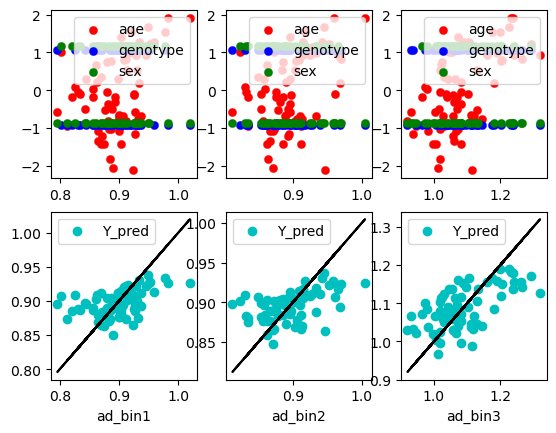

In [37]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y_pred - Y) ** 2)

    if r2 > 0.2:
        print('Weights:')
        print(weights)
        print('MSE:')
        print(mse)
        print('R2:')
        print(r2)
        plt.subplot(2, 3, 1)
        plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 4)
        plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
        plt.plot(Y[:,0], Y[:,0], color='k')
        plt.legend()
        plt.xlabel(type + '_bin1')
        plt.subplot(2, 3, 2)
        plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 5)
        plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
        plt.plot(Y[:,1], Y[:,1], color='k')
        plt.legend()
        plt.xlabel(type + '_bin2')
        plt.subplot(2, 3, 3)
        plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 6)
        plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
        plt.plot(Y[:,2], Y[:,2], color='k')
        plt.legend()
        plt.xlabel(type + '_bin3')
        plt.show()


In [41]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.        ]
 [52.        ]
 [69.     

lh_bankssts
Weights:
[[0.00030587]] [[0.00087668]] [[0.00445973]]
MSE:
0.0013117412783847737 0.0022663431275374906 0.006005890300391002
R2:
0.016387815495681912 0.07340468506916331 0.4361746682980775


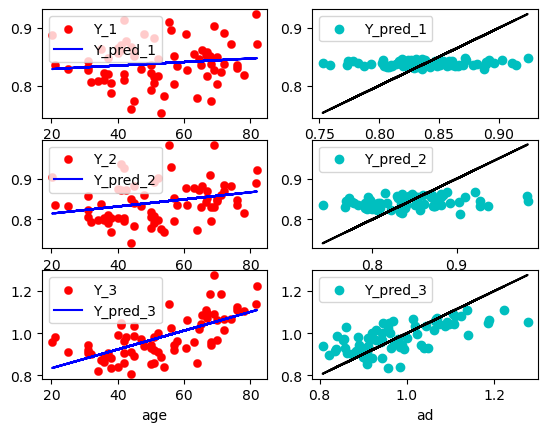

lh_caudalanteriorcingulate
Weights:
[[0.00157423]] [[0.00210089]] [[0.00371654]]
MSE:
0.0039183359695835005 0.003912496338277164 0.006302549902583506
R2:
0.12872519713927433 0.20856518182388828 0.3386068829575811


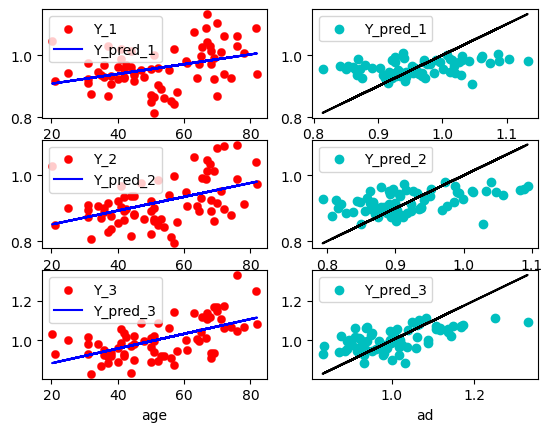

lh_caudalmiddlefrontal
Weights:
[[0.00054592]] [[0.00112373]] [[0.00404438]]
MSE:
0.0012348366684348394 0.0018326968743706692 0.005047329025292868
R2:
0.05337023438143129 0.13864042196724724 0.43086057012791823


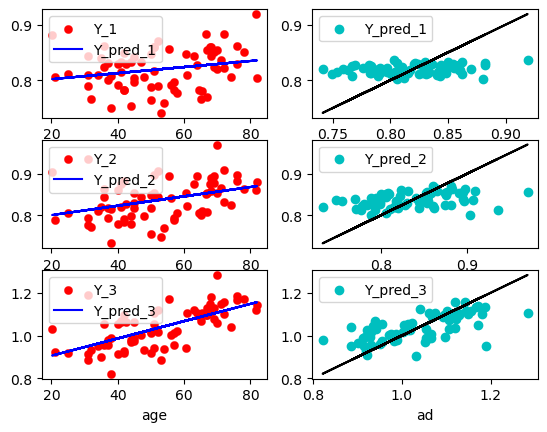

lh_cuneus
Weights:
[[0.00107732]] [[0.00163004]] [[0.00382601]]
MSE:
0.002170026176592446 0.003259690757505454 0.007514171938132645
R2:
0.11106389205365175 0.15995538650383212 0.3127517913119855


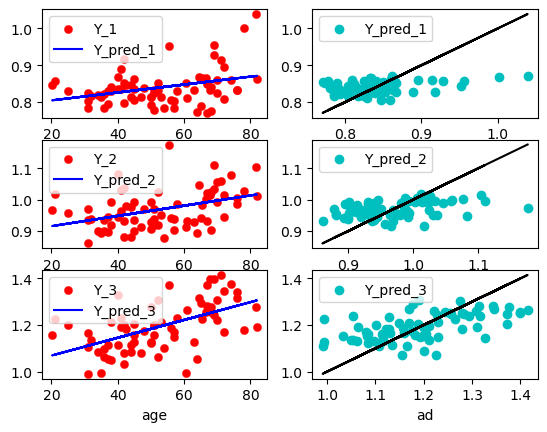

lh_entorhinal
Weights:
[[0.00010124]] [[0.00165179]] [[0.00364378]]
MSE:
0.0045924643492055465 0.006231233034136928 0.008937728721661766
R2:
0.0005210662105107344 0.0927940206935276 0.25761984795614723


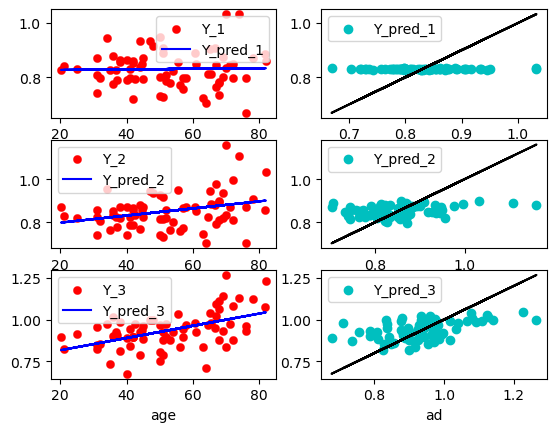

lh_fusiform
Weights:
[[0.00063494]] [[0.00162694]] [[0.00466208]]
MSE:
0.0009114739307409875 0.0015590383831743987 0.004017993705467673
R2:
0.09364778726698053 0.28398071120194546 0.5582350047791131


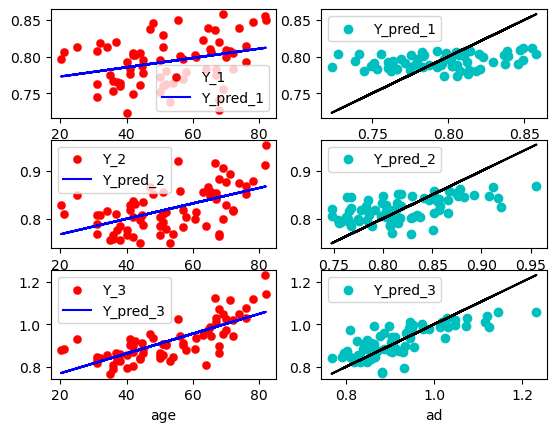

lh_inferiorparietal
Weights:
[[0.00058897]] [[0.00126593]] [[0.00468174]]
MSE:
0.0014673884885443534 0.002544417973250657 0.005904528448560337
R2:
0.05233234250188468 0.1282605467356368 0.464430570473243


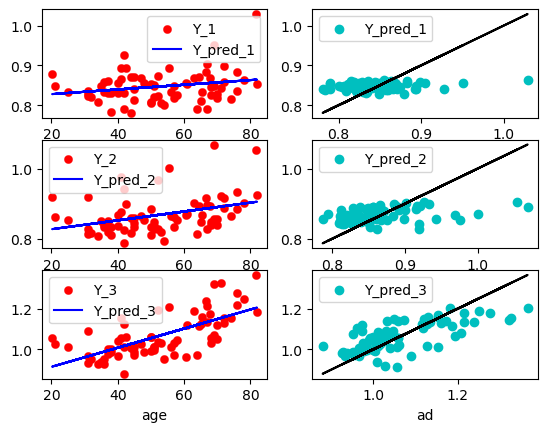

lh_inferiortemporal
Weights:
[[0.00075146]] [[0.00154239]] [[0.00357163]]
MSE:
0.0016410224392416567 0.0023452501256134117 0.004889674273595818
R2:
0.07440457896440611 0.19156674893821635 0.37866532604694314


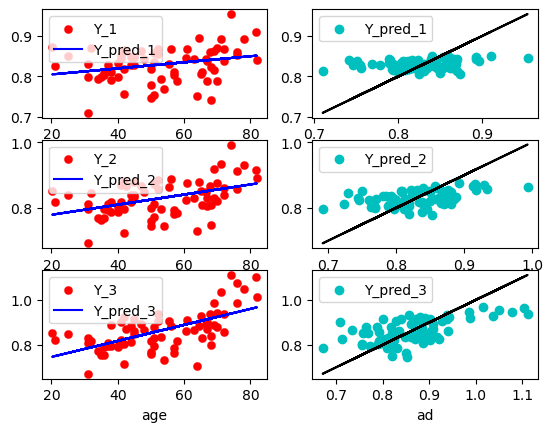

lh_isthmuscingulate
Weights:
[[0.00164669]] [[0.00257715]] [[0.00429632]]
MSE:
0.0036658837592515 0.004500064303211286 0.0078523026069152
R2:
0.1473331312448758 0.25638176410040747 0.35447461305150674


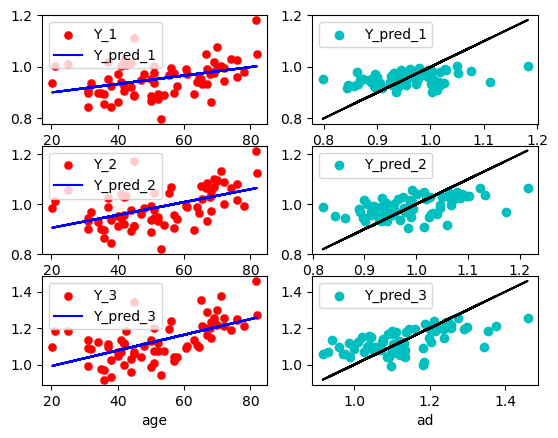

lh_lateraloccipital
Weights:
[[0.00160307]] [[0.00237046]] [[0.00375561]]
MSE:
0.0035424533777546484 0.004619040555475548 0.011005507251842834
R2:
0.1449079216875756 0.2212908263123059 0.23040361844353552


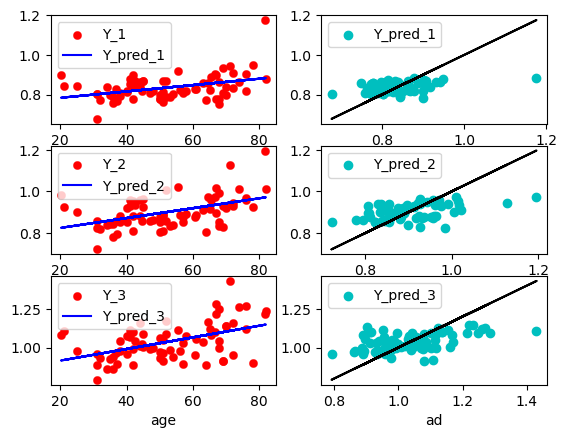

lh_lateralorbitofrontal
lh_lingual
Weights:
[[0.00142745]] [[0.00265545]] [[0.00510895]]
MSE:
0.0023681356173760556 0.004709527732749878 0.00851380292197612
R2:
0.167358062577886 0.259130297087775 0.41730654542456935


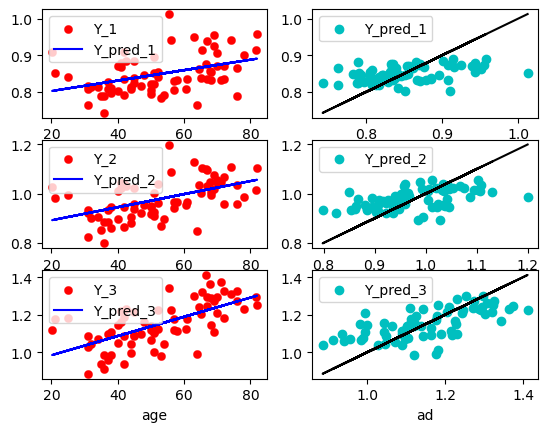

lh_medialorbitofrontal
Weights:
[[0.00128323]] [[0.00177773]] [[0.0027247]]
MSE:
0.0032483366388489665 0.00403720382648685 0.006652847419281342
R2:
0.10588191253585433 0.15459412763032399 0.20677669449867997


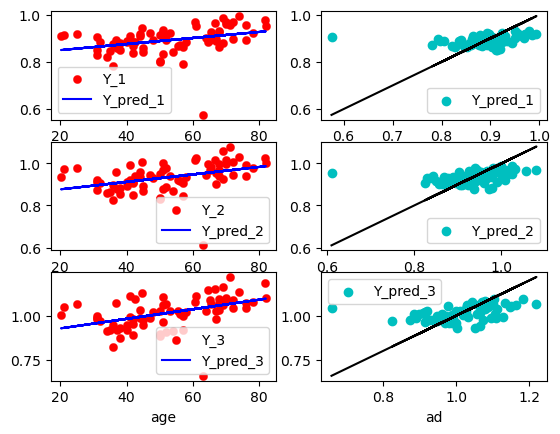

lh_middletemporal
Weights:
[[0.00052775]] [[0.00143653]] [[0.00461246]]
MSE:
0.0012807151477158946 0.0021358572094257924 0.004272738698929086
R2:
0.04834534312431171 0.184140946486824 0.5377110346796243


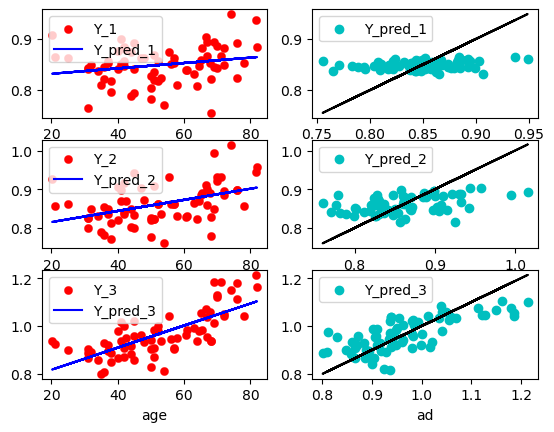

lh_parahippocampal
Weights:
[[0.00069589]] [[0.00157866]] [[0.0035758]]
MSE:
0.002328098294733041 0.0030860117131155697 0.0047419350111317145
R2:
0.046339666690467185 0.15870893136041553 0.386463198950985


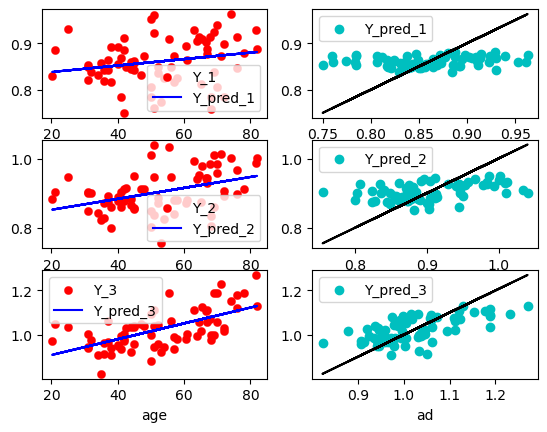

lh_paracentral
Weights:
[[0.00101214]] [[0.00168614]] [[0.00462071]]
MSE:
0.0010717380196267464 0.002898776917255194 0.008324321691579485
R2:
0.18253242628924937 0.1864043165589494 0.374672253032038


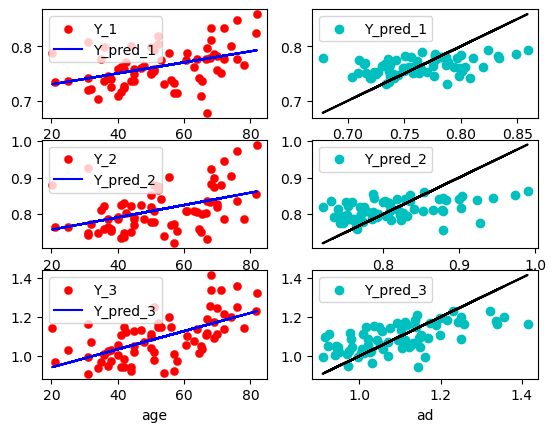

lh_parsopercularis
Weights:
[[0.00029539]] [[0.0011542]] [[0.00373578]]
MSE:
0.001161599962698611 0.0021003388192146373 0.004973029668716117
R2:
0.01724466503034361 0.12904583827705307 0.3959769278061084


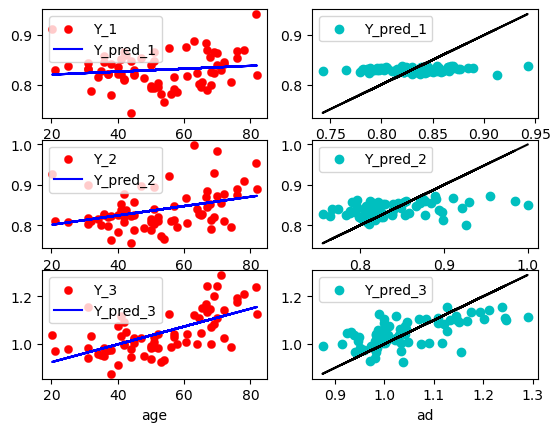

lh_parsorbitalis
Weights:
[[0.0011231]] [[0.00156703]] [[0.00332634]]
MSE:
0.0038095071002900226 0.005828049573566413 0.0067877895448077395
R2:
0.07179378137941783 0.08960556879018822 0.27577411953059494


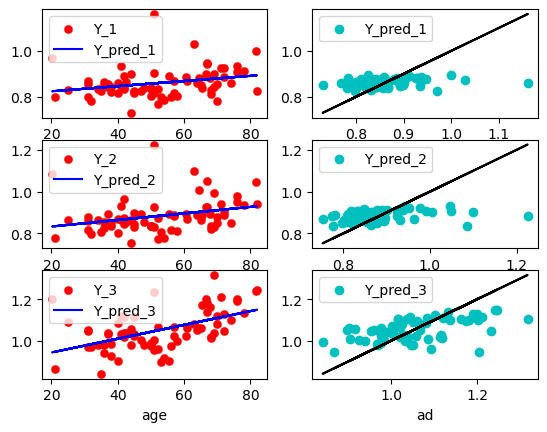

lh_parstriangularis
Weights:
[[0.00083736]] [[0.00158994]] [[0.004167]]
MSE:
0.0021697740783575793 0.002850222409363885 0.005863244674644794
R2:
0.07019128516612905 0.17162580397463945 0.4089161264793648


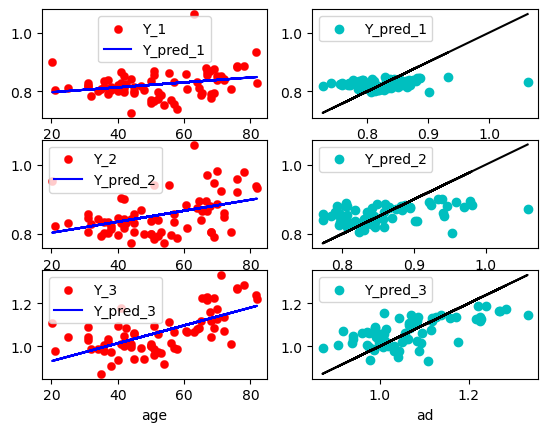

lh_pericalcarine
Weights:
[[0.00206683]] [[0.00320907]] [[0.00478734]]
MSE:
0.0029150039438916014 0.0037944819196342678 0.00969812193909039
R2:
0.25502794614088475 0.38800133441365336 0.3556901517150223


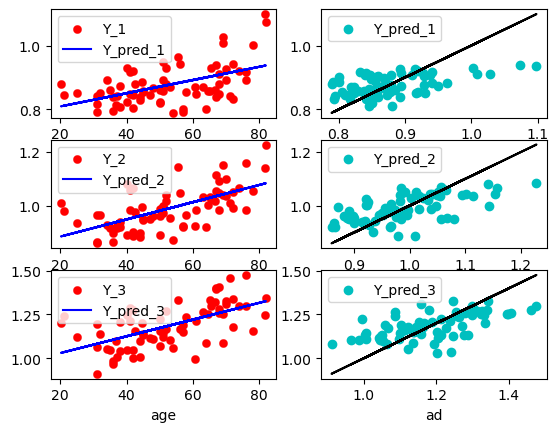

lh_postcentral
Weights:
[[0.00099281]] [[0.00168997]] [[0.0042575]]
MSE:
0.0031057055043011922 0.0063546909384590245 0.010265599433754673
R2:
0.06902185927616089 0.09501289178769945 0.2920245059520673


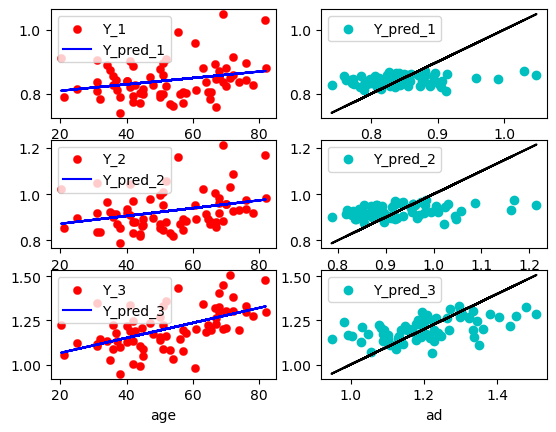

lh_posteriorcingulate
Weights:
[[0.00146732]] [[0.00192951]] [[0.00422634]]
MSE:
0.001483502489322399 0.0019235153407008276 0.00576225249500258
R2:
0.25318965518710146 0.3113620309835843 0.41999505116488933


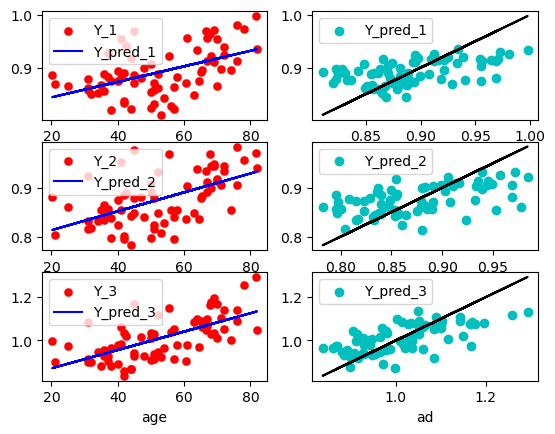

lh_precentral
Weights:
[[0.00066342]] [[0.00088965]] [[0.00342881]]
MSE:
0.0010734132483205608 0.0019044625886562641 0.007116620127354628
R2:
0.08741117465947179 0.088491573022484 0.2784540903224293


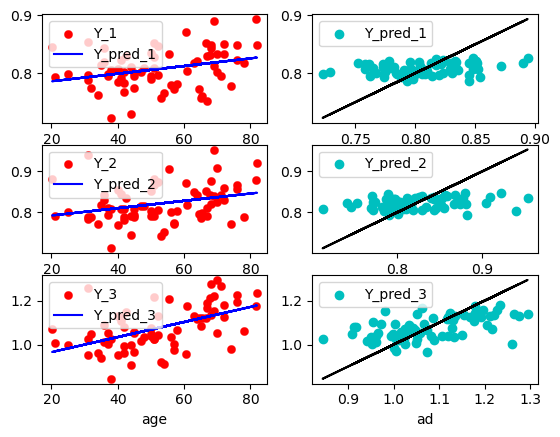

lh_precuneus
Weights:
[[0.00074538]] [[0.00159633]] [[0.00464598]]
MSE:
0.0010816136673724931 0.002439850461014527 0.005741323398697996
R2:
0.10713728907331865 0.1961292385912966 0.4675894240107846


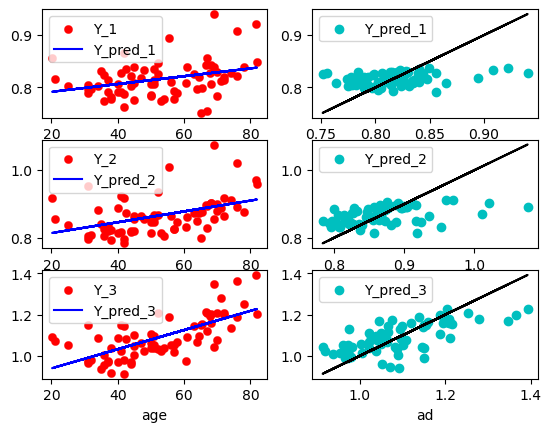

lh_rostralanteriorcingulate
Weights:
[[0.0018232]] [[0.00154677]] [[0.0025279]]
MSE:
0.003723914926402997 0.002792856916517571 0.004365412046751164
R2:
0.1725411853207539 0.16674682737940327 0.25481962161006844


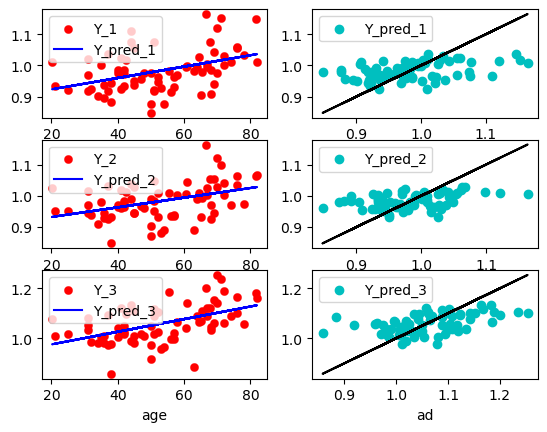

lh_rostralmiddlefrontal
Weights:
[[0.00022148]] [[0.000978]] [[0.00358782]]
MSE:
0.0016801194611476705 0.002050816856859999 0.004429503725465886
R2:
0.006774394581819276 0.09824544326967743 0.40435917541933863


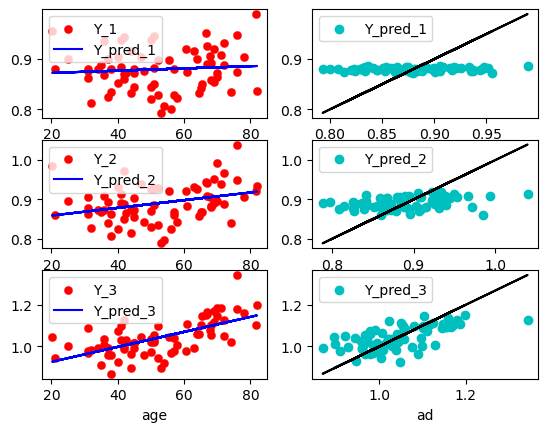

lh_superiorfrontal
Weights:
[[0.00051004]] [[0.00103129]] [[0.00306493]]
MSE:
0.001292596502790213 0.0019599543462018266 0.004281481379826539
R2:
0.04490244555123091 0.11250161708661321 0.33885785006045777


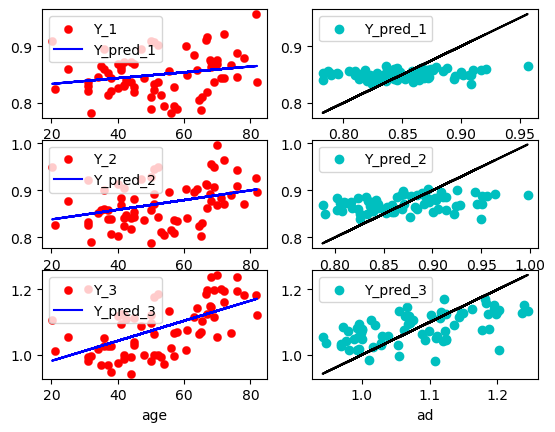

lh_superiorparietal
Weights:
[[0.00078534]] [[0.00147598]] [[0.00364363]]
MSE:
0.001544973751635976 0.0038284128469792027 0.007648327143768971
R2:
0.08530024449377616 0.1173323737687022 0.2885028869726537


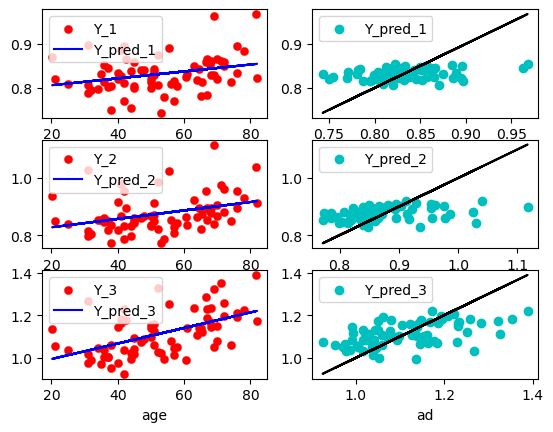

lh_superiortemporal
Weights:
[[0.00029222]] [[0.00115839]] [[0.00437139]]
MSE:
0.0008457979696784734 0.002324303740640523 0.005359928851327393
R2:
0.023041595716081886 0.11883669280309495 0.45439498807887846


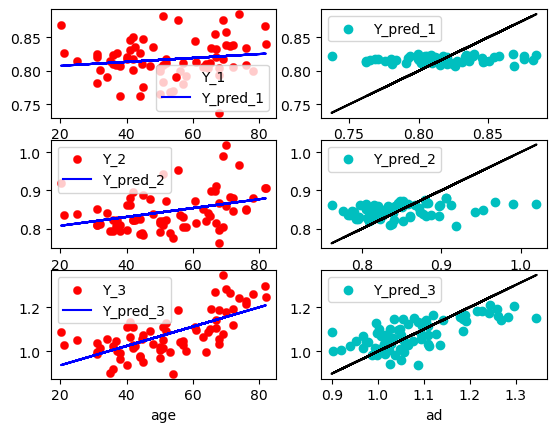

lh_supramarginal
Weights:
[[0.00070431]] [[0.0016003]] [[0.00477802]]
MSE:
0.0012972893379690775 0.002636712478723743 0.0062616457819117295
R2:
0.08199899709022485 0.18493044189130925 0.4599536515801649


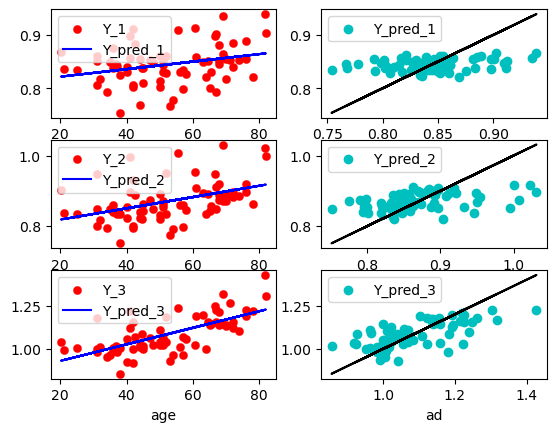

lh_frontalpole
lh_temporalpole
lh_transversetemporal
Weights:
[[-0.00037489]] [[0.00036417]] [[0.00530643]]
MSE:
0.0011373741000281295 0.0038521316681837006 0.009790439685967066
R2:
0.02805521272682099 0.007978148759887005 0.40186319772007395


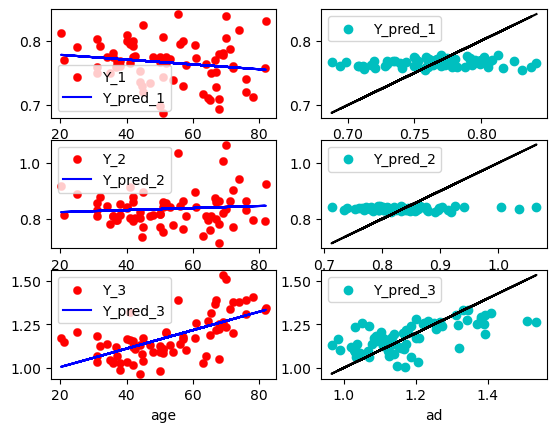

lh_insula
Weights:
[[0.0011432]] [[0.0010616]] [[0.00354004]]
MSE:
0.0014527867336636968 0.0012571702483744531 0.005372503040810928
R2:
0.1736525993339657 0.17315232863391627 0.3527079960677111


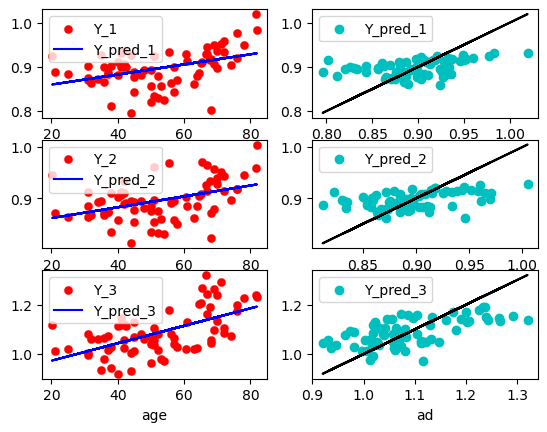

In [42]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()


rh_bankssts
Weights:
[[0.00046401]] [[0.00120492]] [[0.00467717]]
MSE:
0.0008468793435994968 0.0017047878141877183 0.005891464831737918
R2:
0.056060320293543575 0.16592929866532868 0.46449575375317753


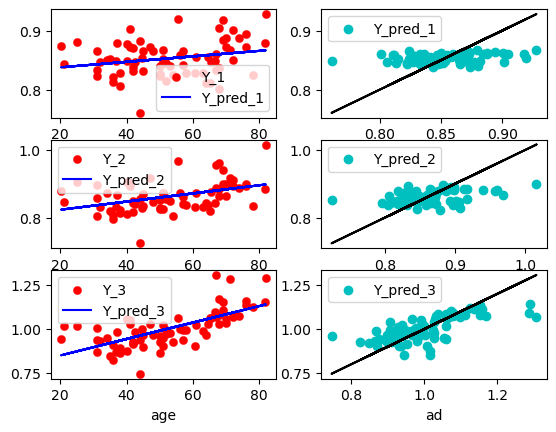

rh_caudalanteriorcingulate
Weights:
[[0.00163923]] [[0.00229802]] [[0.00402824]]
MSE:
0.002930994645108832 0.003533157250351452 0.005921294059443147
R2:
0.17638652796001375 0.25879692613936134 0.39030434391238034


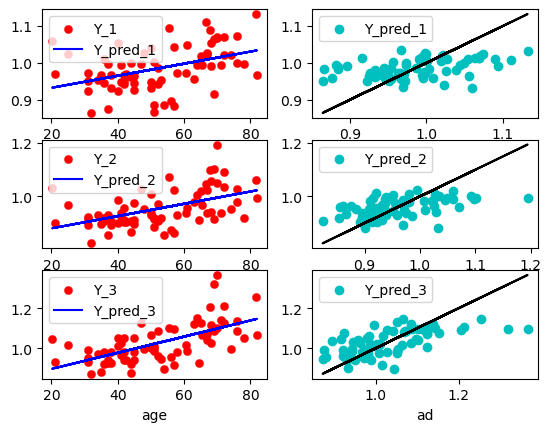

rh_caudalmiddlefrontal
Weights:
[[0.00019661]] [[0.00054931]] [[0.00384236]]
MSE:
0.0011981052961819222 0.001658772955277589 0.004054839565876679
R2:
0.007480227838592368 0.04076217132902449 0.4596189816265167


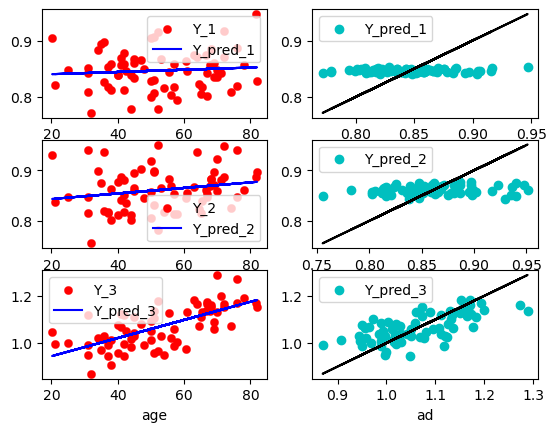

rh_cuneus
Weights:
[[0.00058003]] [[0.00164544]] [[0.00488728]]
MSE:
0.0014847077578004993 0.003321578700268245 0.008238183500727055
R2:
0.050272828773061606 0.15995502801883366 0.40380211419507817


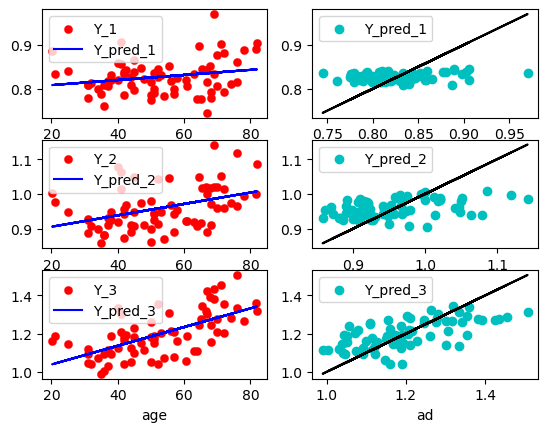

rh_entorhinal
rh_fusiform
Weights:
[[0.00076444]] [[0.00185069]] [[0.00499162]]
MSE:
0.0012449824128601273 0.002067535824065209 0.005594391181842413
R2:
0.09881331283806571 0.2790097977455799 0.5099034674390992


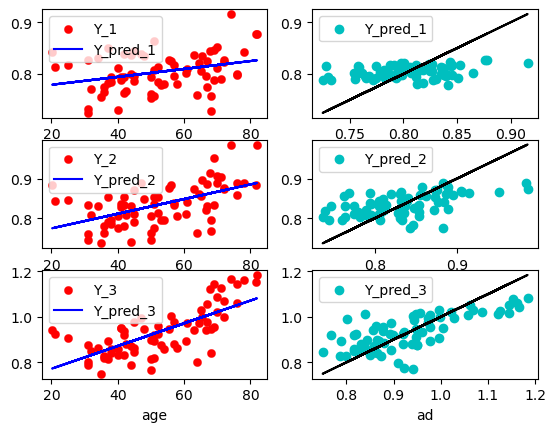

rh_inferiorparietal
Weights:
[[0.00047969]] [[0.00119943]] [[0.00449422]]
MSE:
0.000794020987244032 0.001420170140088625 0.003914704593241562
R2:
0.06340442376307853 0.1913555621551879 0.5465413976311934


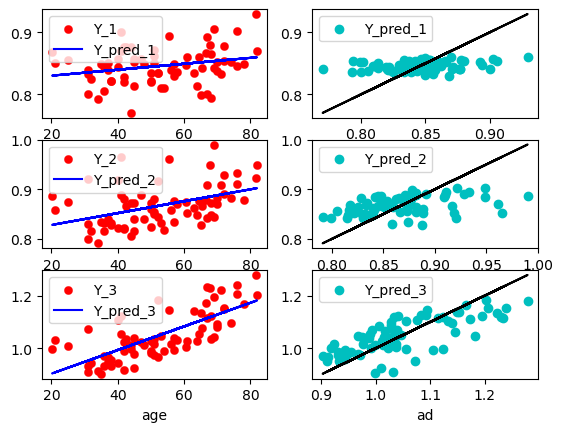

rh_inferiortemporal
Weights:
[[0.00100761]] [[0.00154045]] [[0.00312472]]
MSE:
0.0015750359004473966 0.0023242906256629088 0.00465575156746849
R2:
0.1308730334044127 0.19256972335956368 0.32881404073814324


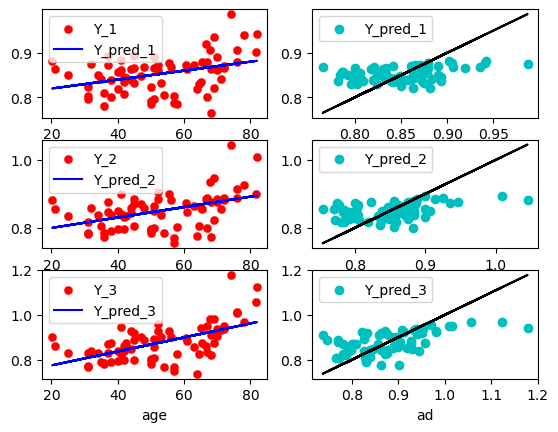

rh_isthmuscingulate
Weights:
[[0.00187012]] [[0.00283699]] [[0.00458038]]
MSE:
0.003300211285979502 0.004559462236665532 0.007688327264612527
R2:
0.19843220805369333 0.2919662271635951 0.3892949105774173


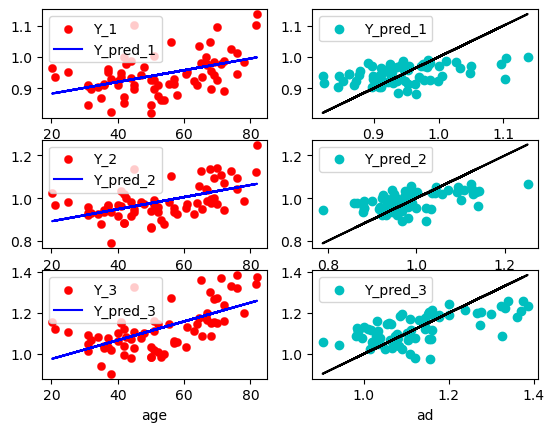

rh_lateraloccipital
Weights:
[[0.00131691]] [[0.0021253]] [[0.00360428]]
MSE:
0.0019341793318890846 0.003685095702284845 0.00994581214227344
R2:
0.17318041563887077 0.22259553043758684 0.23378783365184597


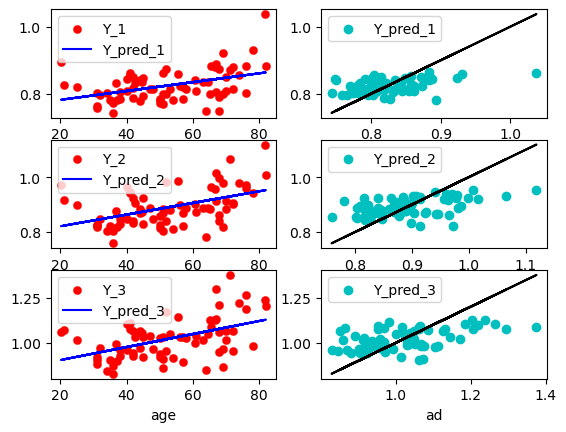

rh_lateralorbitofrontal
rh_lingual
Weights:
[[0.00110118]] [[0.00253346]] [[0.00526416]]
MSE:
0.0024340355684337157 0.004723454993099574 0.009614088368460639
R2:
0.1042451232208571 0.2409443019436598 0.4023879292754774


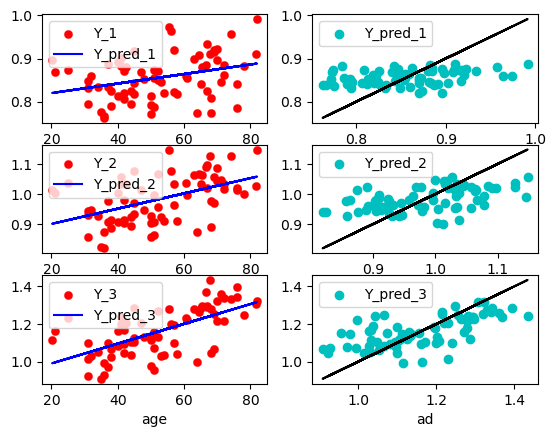

rh_medialorbitofrontal
Weights:
[[0.00159412]] [[0.00216398]] [[0.0031738]]
MSE:
0.0024872108576653143 0.0030029449375794546 0.0044308159905539135
R2:
0.19268468348887924 0.2670116079516388 0.3468623606739497


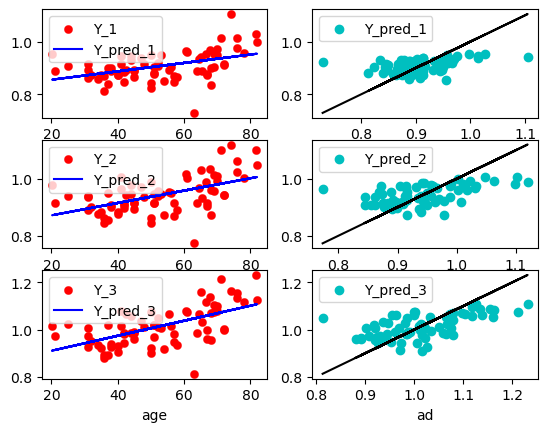

rh_middletemporal
Weights:
[[0.00070092]] [[0.00153722]] [[0.00444154]]
MSE:
0.001151103151140045 0.001753839890221091 0.003974248804426106
R2:
0.09066225345916001 0.2393965064689617 0.5369400816642432


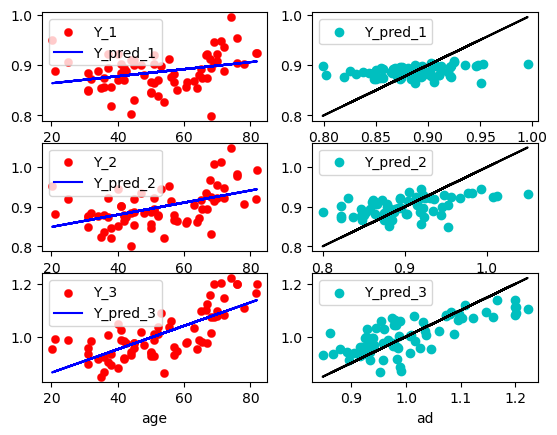

rh_parahippocampal
Weights:
[[0.00067758]] [[0.00163405]] [[0.00377615]]
MSE:
0.0033256877344576222 0.004032836524745057 0.00538686379074567
R2:
0.031241468393624627 0.1339490526425 0.38208878436898586


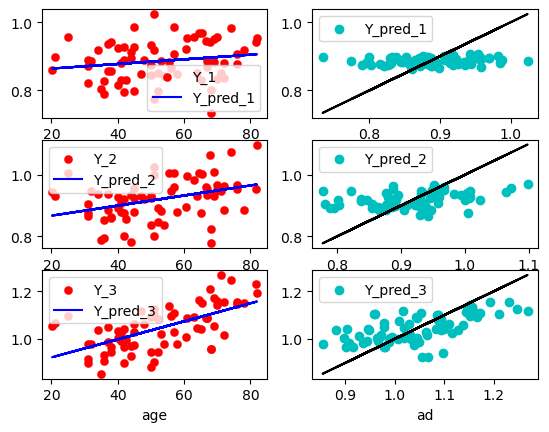

rh_paracentral
Weights:
[[0.00074991]] [[0.00124881]] [[0.00374247]]
MSE:
0.0008647511307064437 0.0023136223777650666 0.008110224771850166
R2:
0.13188089212714327 0.1360411561473337 0.2874558020114787


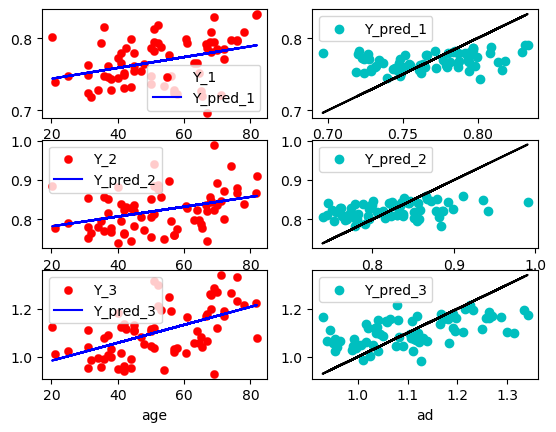

rh_parsopercularis
Weights:
[[0.00043883]] [[0.00111198]] [[0.00367176]]
MSE:
0.001133547118502176 0.0017310164850884895 0.0043597302159406924
R2:
0.03817028884026796 0.14300457726211613 0.41940795370660866


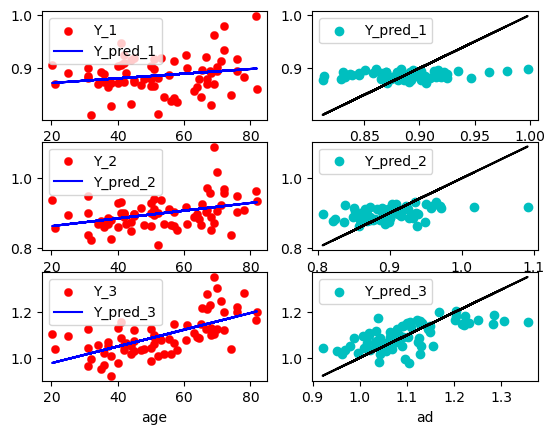

rh_parsorbitalis
Weights:
[[0.00098567]] [[0.00147003]] [[0.00396849]]
MSE:
0.00226062847435061 0.004264587667716635 0.00697978354294269
R2:
0.09123441087796602 0.10584357307963932 0.3451591304113021


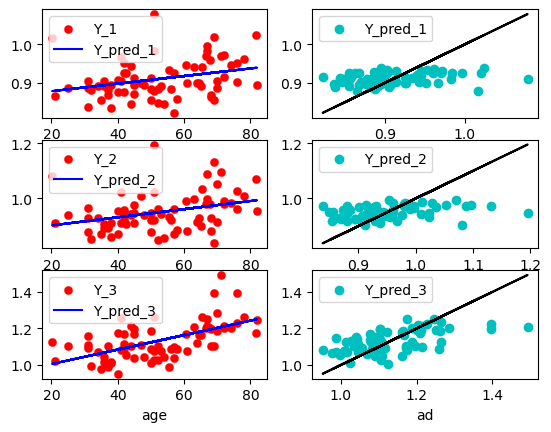

rh_parstriangularis
Weights:
[[0.00075571]] [[0.00149244]] [[0.00411322]]
MSE:
0.001516004997615921 0.002816991803591043 0.007151636315424325
R2:
0.08088341613848393 0.15590897329636588 0.3559311914038956


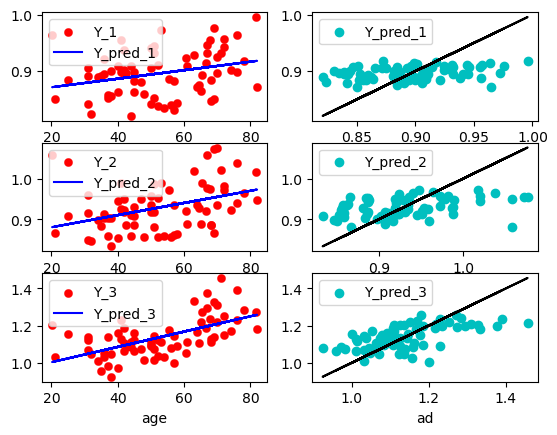

rh_pericalcarine
Weights:
[[0.0017725]] [[0.00295585]] [[0.0050051]]
MSE:
0.0025026638892490165 0.004406547650488093 0.010018982004789448
R2:
0.22675750084655322 0.3165537166148983 0.36872181706355867


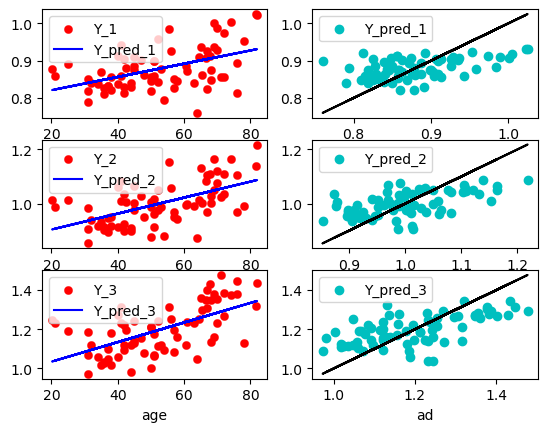

rh_postcentral
Weights:
[[0.00039029]] [[0.00107116]] [[0.00382651]]
MSE:
0.0018867844278763987 0.0038868936219590244 0.006504297218706622
R2:
0.018510377886892804 0.06450908941477429 0.3446381417265528


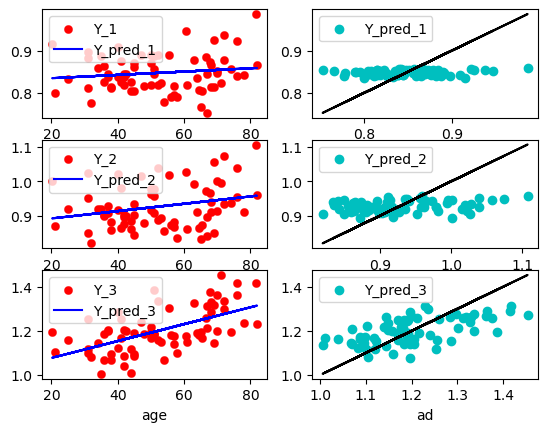

rh_posteriorcingulate
Weights:
[[0.00108193]] [[0.00152896]] [[0.00402871]]
MSE:
0.0016477712457348783 0.0017969422321096498 0.005034386934123689
R2:
0.14233027117639052 0.23307035894228312 0.42958726234149835


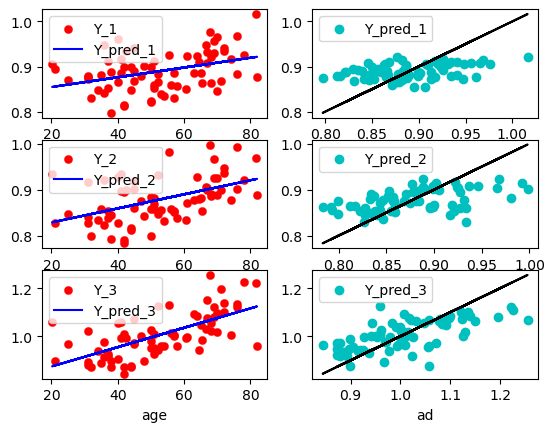

rh_precentral
Weights:
[[0.00012252]] [[0.00049828]] [[0.00356642]]
MSE:
0.0008534818575010196 0.0012544399253804242 0.006359043264774797
R2:
0.004092074588651462 0.044192499004374164 0.3184525227886488


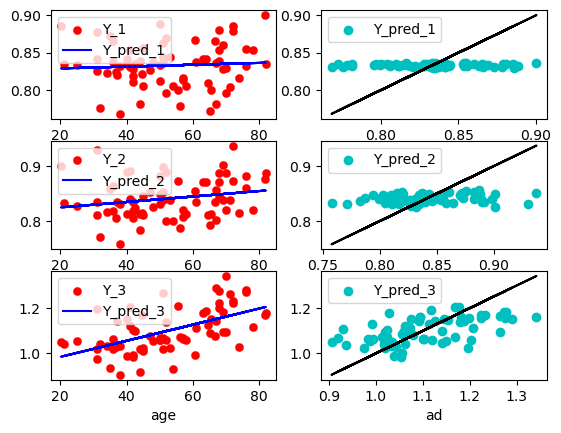

rh_precuneus
Weights:
[[0.00066602]] [[0.00159059]] [[0.00437792]]
MSE:
0.0008671911896534827 0.0019434379532640375 0.005058890700105213
R2:
0.10673710710128592 0.23318955177983924 0.4695029847670361


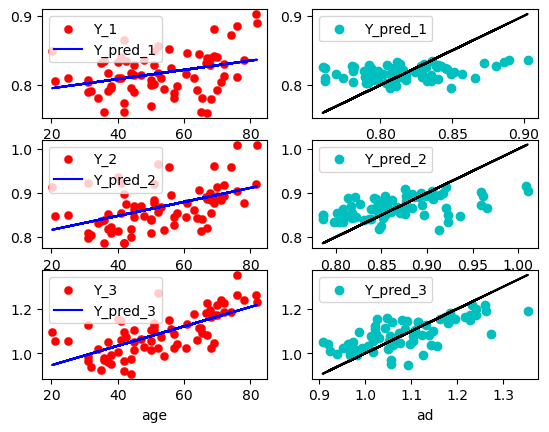

rh_rostralanteriorcingulate
Weights:
[[0.00092098]] [[0.00122248]] [[0.0032068]]
MSE:
0.0037526322534911912 0.0024418161670111873 0.0033669992659791865
R2:
0.05015278232414688 0.1250867069129893 0.41639010698396717


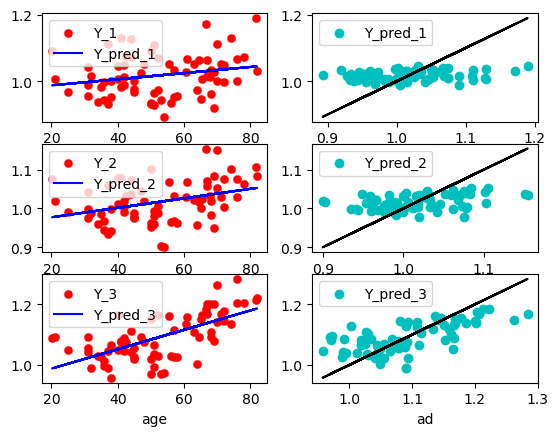

rh_rostralmiddlefrontal
Weights:
[[0.00041552]] [[0.00116644]] [[0.00391384]]
MSE:
0.0016292171396654175 0.002259964358129963 0.00499891621856538
R2:
0.02415813853585269 0.12329701420302586 0.4171899528612344


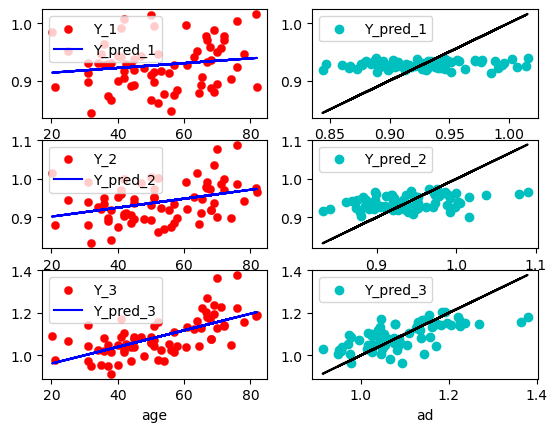

rh_superiorfrontal
Weights:
[[0.00041957]] [[0.00091152]] [[0.00298136]]
MSE:
0.0011996804403542312 0.001586052394585796 0.004073679991158518
R2:
0.033141519478586456 0.10903168884615799 0.3376181105605487


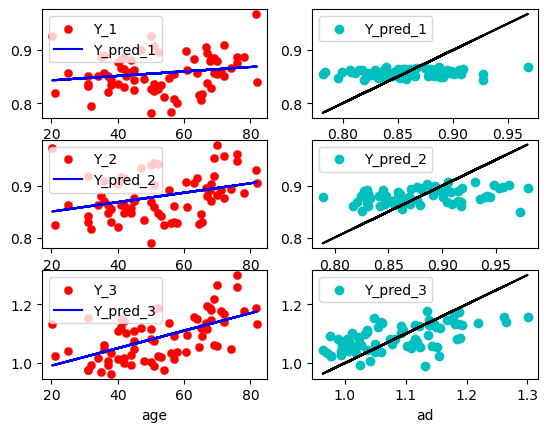

rh_superiorparietal
Weights:
[[0.00063344]] [[0.00121198]] [[0.00322824]]
MSE:
0.001430823998635672 0.0034124116220225023 0.007611143359797049
R2:
0.06148129225052967 0.09136780364624186 0.24234260735430735


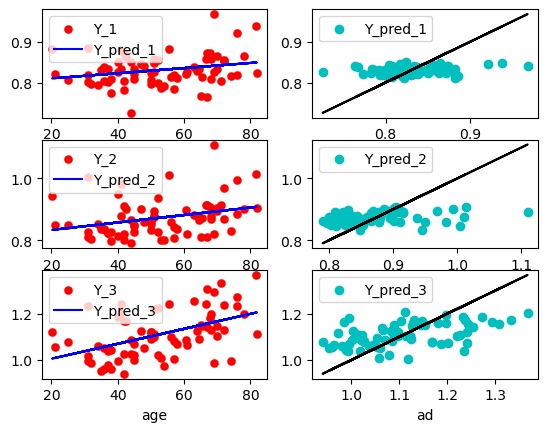

rh_superiortemporal
Weights:
[[0.00079317]] [[0.0016826]] [[0.00494576]]
MSE:
0.0011927769329602002 0.0024861159914648452 0.005129232001057174
R2:
0.10969405295103718 0.21012452150279848 0.526965169506584


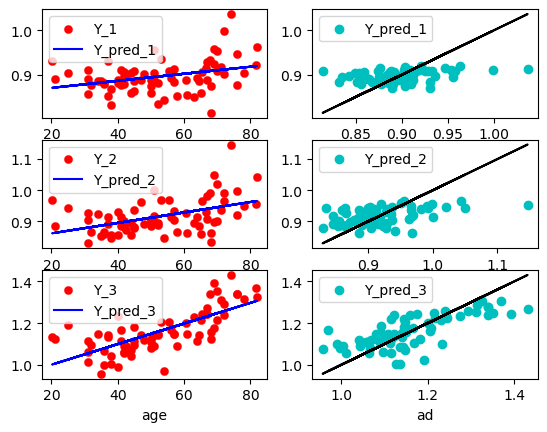

rh_supramarginal
Weights:
[[0.00064545]] [[0.00152618]] [[0.00493577]]
MSE:
0.000791205881052105 0.0016795982184029594 0.0046513995837266855
R2:
0.10952923944611925 0.2446868194432137 0.5502569933840591


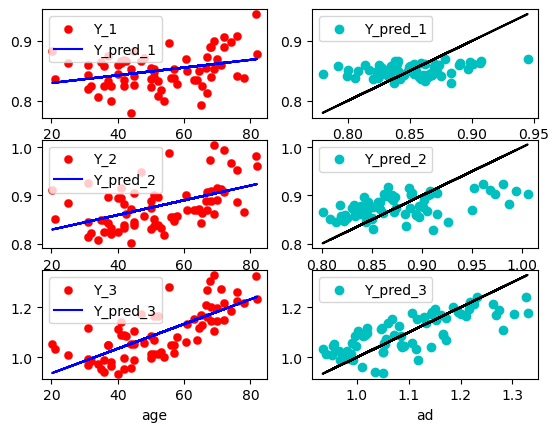

rh_frontalpole
rh_temporalpole
rh_transversetemporal
Weights:
[[-0.00026055]] [[0.00024979]] [[0.00613537]]
MSE:
0.0017898867124800826 0.0044081328596478255 0.012368149969469616
R2:
0.00878217725971897 0.0032956021309547 0.41553719900930974


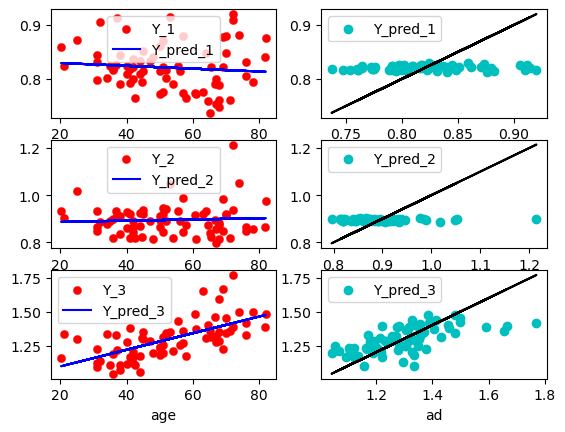

rh_insula
Weights:
[[0.00142848]] [[0.00151739]] [[0.00401681]]
MSE:
0.00145915579014517 0.0018716902620575725 0.005250436578958483
R2:
0.2462382889723317 0.22322015771628156 0.4178820034796913


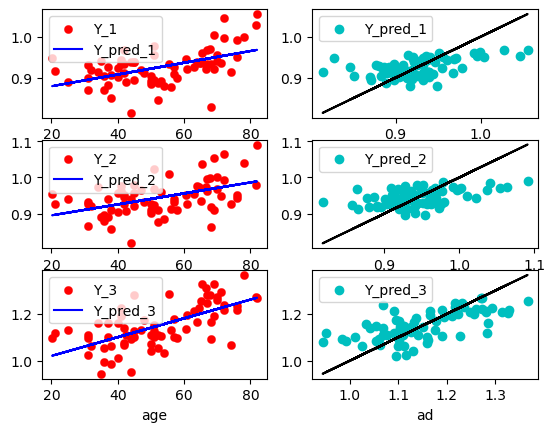

In [40]:
# For left hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()
